In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load the dataset
df = pd.read_excel("data1-telematics_syn_orignal data.xlsx", index_col=0)

# Data Cleaning and Feature Engineering

# Define age groups
age_dict = {
    'young_drivers': {'age_bracket': '16-25', 'bins': [16, 25]},
    'middle_drivers': {'age_bracket': '26-40', 'bins': [26, 40]},
    'mature_drivers': {'age_bracket': '41-60', 'bins': [41, 60]},
    'senior_drivers': {'age_bracket': '61+', 'bins': [61, df['Insured.age'].max()]}
}
age_bin_list = [16]
age_bin_list.extend([age_dict[x]['bins'][1] for x in age_dict])
age_bin_labels = [age_dict[x]['age_bracket'] for x in age_dict]
df['age_group'] = pd.cut(df['Insured.age'], bins=age_bin_list, labels=age_bin_labels, include_lowest=True)

# Define credit score groups
credit_score_bins = [300, 600, 700, 800, 850]
credit_score_labels = ['Poor', 'Fair', 'Good', 'Excellent']
df['credit_score_group'] = pd.cut(df['Credit.score'], bins=credit_score_bins, labels=credit_score_labels, include_lowest=True)

# Define annual mileage groups
annual_miles_bins = [0, 10000, 15000, 20000, df['Annual.miles.drive'].max()]
annual_miles_labels = ['0-10k', '10k-15k', '15k-20k', '20k+']
df['annual_miles_group'] = pd.cut(df['Annual.miles.drive'], bins=annual_miles_bins, labels=annual_miles_labels, include_lowest=True)

# Define car age groups
car_age_bins = [0, 5, 10, 15, df['Car.age'].max()]
car_age_labels = ['0-5', '6-10', '11-15', '15+']
df['car_age_group'] = pd.cut(df['Car.age'], bins=car_age_bins, labels=car_age_labels, include_lowest=True)

# Define years no claims groups
years_noclaims_bins = [0, 2, 4, 6, df['Years.noclaims'].max()]
years_noclaims_labels = ['0-2', '3-4', '5-6', '6+']
df['years_noclaims_group'] = pd.cut(df['Years.noclaims'], bins=years_noclaims_bins, labels=years_noclaims_labels, include_lowest=True)

# Remove original columns that have been grouped
columns_to_remove = ['Insured.age', 'Credit.score', 'Annual.miles.drive', 'Car.age', 'Years.noclaims']
df.drop(columns=columns_to_remove, inplace=True)

# Handle missing values
numeric_cols = df.select_dtypes(include=['number']).columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns

# Fill NaN values in numeric columns with the mean
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill NaN values in non-numeric columns with the mode
for col in non_numeric_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# One-hot encode categorical variables
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
encoder = OneHotEncoder(sparse=False, drop='first')
encoded_categorical = encoder.fit_transform(df[categorical_cols])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_cols))

# Combine the numeric and encoded categorical columns
df_combined = pd.concat([df[numeric_cols].reset_index(drop=True), encoded_categorical_df.reset_index(drop=True)], axis=1)

# Scale the combined features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_combined)

# Define the target variables
target_claim_frequency = df['NB_Claim']
target_claim_cost = df['AMT_Claim']

# Create a new DataFrame including severity
df_final = pd.DataFrame(features_scaled, columns=df_combined.columns)
df_final['NB_Claim'] = target_claim_frequency.reset_index(drop=True)
df_final['AMT_Claim'] = target_claim_cost.reset_index(drop=True)
df_final['Severity'] = df_final.apply(lambda row: row['AMT_Claim'] if row['NB_Claim'] > 0 else 0, axis=1)

# Save the prepared dataset to a new CSV file (optional)
df_final.to_csv('prepared_data.csv', index=False)

/Users/joco/anaconda3/envs/graphmining/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [13]:
# Visual inspection of the DataFrame
df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 64 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Territory                   100000 non-null  float64
 1   Annual.pct.driven           100000 non-null  float64
 2   Total.miles.driven          100000 non-null  float64
 3   Pct.drive.mon               100000 non-null  float64
 4   Pct.drive.tue               100000 non-null  float64
 5   Pct.drive.wed               100000 non-null  float64
 6   Pct.drive.thr               100000 non-null  float64
 7   Pct.drive.fri               100000 non-null  float64
 8   Pct.drive.sat               100000 non-null  float64
 9   Pct.drive.sun               100000 non-null  float64
 10  Pct.drive.2hrs              100000 non-null  float64
 11  Pct.drive.3hrs              100000 non-null  float64
 12  Pct.drive.4hrs              100000 non-null  float64
 13  Pct.drive.wkday

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Function to calculate performance metrics
def calculate_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Function to calculate loss cost
def calculate_loss_cost(y_freq, y_cost):
    return y_freq * y_cost

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import PoissonRegressor, LinearRegression
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary
results_glm = {
    'Model': 'GLM',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate the GLM model
for train_index, test_index in cv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Train Poisson Regressor for claim frequency
    poisson_regressor = PoissonRegressor()
    poisson_regressor.fit(X_train, y_train_freq)
    y_pred_claim_frequency = poisson_regressor.predict(X_test)
    
    # Train Linear Regression for severity
    linear_regressor = LinearRegression()
    linear_regressor.fit(X_train, y_train_severity)
    y_pred_severity = linear_regressor.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_glm['RMSE_Frequency'].append(rmse_freq)
    results_glm['MAE_Frequency'].append(mae_freq)
    results_glm['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_glm['RMSE_Severity'].append(rmse_severity)
    results_glm['MAE_Severity'].append(mae_severity)
    results_glm['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_glm['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_glm['MAE_Loss_Cost'].append(mae_loss_cost)
    results_glm['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_glm:
    if key != 'Model':
        results_glm[key] = np.mean(results_glm[key])

# Print the results
print("GLM Model Results:")
print(results_glm)


GLM Model Results:
{'Model': 'GLM', 'RMSE_Frequency': 0.21728958971309437, 'MAE_Frequency': 0.08577112110617416, 'R2_Frequency': 0.007272749835885617, 'RMSE_Severity': 1247.1937387804305, 'MAE_Severity': 283.48387807761526, 'R2_Severity': 0.0179472117278759, 'RMSE_Loss_Cost': 1481.026434643282, 'MAE_Loss_Cost': 158.76860024126023, 'R2_Loss_Cost': -0.008052771941927305}


In [17]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary
results_gam = {
    'Model': 'GAM',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate the GAM model
for train_index, test_index in cv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Train GAM for claim frequency
    gam_freq = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10)).fit(X_train, y_train_freq)
    y_pred_claim_frequency = gam_freq.predict(X_test)
    
    # Train GAM for severity
    gam_severity = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10)).fit(X_train, y_train_severity)
    y_pred_severity = gam_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_gam['RMSE_Frequency'].append(rmse_freq)
    results_gam['MAE_Frequency'].append(mae_freq)
    results_gam['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_gam['RMSE_Severity'].append(rmse_severity)
    results_gam['MAE_Severity'].append(mae_severity)
    results_gam['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_gam['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_gam['MAE_Loss_Cost'].append(mae_loss_cost)
    results_gam['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_gam:
    if key != 'Model':
        results_gam[key] = np.mean(results_gam[key])

# Print the results
print("GAM Model Results:")
print(results_gam)


GAM Model Results:
{'Model': 'GAM', 'RMSE_Frequency': 0.21365942129008345, 'MAE_Frequency': 0.08421133628224252, 'R2_Frequency': 0.040128751410994125, 'RMSE_Severity': 1252.7468299393304, 'MAE_Severity': 267.1395394542709, 'R2_Severity': 0.009201937174826137, 'RMSE_Loss_Cost': 1480.2978839165457, 'MAE_Loss_Cost': 161.4526739787371, 'R2_Loss_Cost': -0.007045824724787986}


In [19]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary
results_xgb = {
    'Model': 'XGBoost',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate the XGBoost model
for train_index, test_index in cv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Train XGBoost Regressor for claim frequency
    xgb_regressor_freq = xgb.XGBRegressor(objective='reg:squarederror')
    xgb_regressor_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = xgb_regressor_freq.predict(X_test)
    
    # Train XGBoost Regressor for severity
    xgb_regressor_severity = xgb.XGBRegressor(objective='reg:squarederror')
    xgb_regressor_severity.fit(X_train, y_train_severity)
    y_pred_severity = xgb_regressor_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_xgb['RMSE_Frequency'].append(rmse_freq)
    results_xgb['MAE_Frequency'].append(mae_freq)
    results_xgb['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_xgb['RMSE_Severity'].append(rmse_severity)
    results_xgb['MAE_Severity'].append(mae_severity)
    results_xgb['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_xgb['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_xgb['MAE_Loss_Cost'].append(mae_loss_cost)
    results_xgb['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_xgb:
    if key != 'Model':
        results_xgb[key] = np.mean(results_xgb[key])

# Print the results
print("XGBoost Model Results:")
print(results_xgb)


XGBoost Model Results:
{'Model': 'XGBoost', 'RMSE_Frequency': 0.18805399637273998, 'MAE_Frequency': 0.07580780833982385, 'R2_Frequency': 0.25630457961487485, 'RMSE_Severity': 1089.7994168119744, 'MAE_Severity': 264.32743503671946, 'R2_Severity': 0.24738004996211096, 'RMSE_Loss_Cost': 1299.2862074126297, 'MAE_Loss_Cost': 147.61459672075685, 'R2_Loss_Cost': 0.21886391020710355}


In [20]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary
results_lgb = {
    'Model': 'LightGBM',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate the LightGBM model
for train_index, test_index in cv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Train LightGBM Regressor for claim frequency
    lgb_regressor_freq = lgb.LGBMRegressor(objective='regression')
    lgb_regressor_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = lgb_regressor_freq.predict(X_test)
    
    # Train LightGBM Regressor for severity
    lgb_regressor_severity = lgb.LGBMRegressor(objective='regression')
    lgb_regressor_severity.fit(X_train, y_train_severity)
    y_pred_severity = lgb_regressor_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_lgb['RMSE_Frequency'].append(rmse_freq)
    results_lgb['MAE_Frequency'].append(mae_freq)
    results_lgb['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_lgb['RMSE_Severity'].append(rmse_severity)
    results_lgb['MAE_Severity'].append(mae_severity)
    results_lgb['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_lgb['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_lgb['MAE_Loss_Cost'].append(mae_loss_cost)
    results_lgb['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_lgb:
    if key != 'Model':
        results_lgb[key] = np.mean(results_lgb[key])

# Print the results
print("LightGBM Model Results:")
print(results_lgb)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005509 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8508
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 61
[LightGBM] [Info] Start training from score 0.044663
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8508
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 61
[LightGBM] [Info] Start training from score 138.745673
[LightGBM] [Warning] Found

In [23]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary
results_rf = {
    'Model': 'Random Forest',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate the Random Forest model
for train_index, test_index in cv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Train Random Forest Regressor for claim frequency
    rf_regressor_freq = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', random_state=42)
    rf_regressor_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = rf_regressor_freq.predict(X_test)
    
    # Train Random Forest Regressor for severity
    rf_regressor_severity = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', random_state=42)
    rf_regressor_severity.fit(X_train, y_train_severity)
    y_pred_severity = rf_regressor_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_rf['RMSE_Frequency'].append(rmse_freq)
    results_rf['MAE_Frequency'].append(mae_freq)
    results_rf['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_rf['RMSE_Severity'].append(rmse_severity)
    results_rf['MAE_Severity'].append(mae_severity)
    results_rf['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_rf['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_rf['MAE_Loss_Cost'].append(mae_loss_cost)
    results_rf['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_rf:
    if key != 'Model':
        results_rf[key] = np.mean(results_rf[key])

# Print the results
print("Random Forest Model Results:")
print(results_rf)


Random Forest Model Results:
{'Model': 'Random Forest', 'RMSE_Frequency': 0.20059160043769797, 'MAE_Frequency': 0.0773066140392756, 'R2_Frequency': 0.1537938557773446, 'RMSE_Severity': 1122.3825356296165, 'MAE_Severity': 234.41263264061368, 'R2_Severity': 0.20519821205663719, 'RMSE_Loss_Cost': 1405.7353033591928, 'MAE_Loss_Cost': 154.81749868671096, 'R2_Loss_Cost': 0.09094962772976463}


In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Reshape features for LSTM
X_reshaped = X.values.reshape((X.shape[0], X.shape[1], 1))

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary
results_lstm = {
    'Model': 'LSTM',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Function to build the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train and evaluate the LSTM model
for fold, (train_index, test_index) in enumerate(cv.split(X_reshaped)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_reshaped[train_index], X_reshaped[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Diagnostic prints
    print(f"Shape of X_train: {X_train.shape}, y_train_freq: {y_train_freq.shape}, y_train_severity: {y_train_severity.shape}")
    
    # Train LSTM for claim frequency
    lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
    lstm_regressor_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = lstm_regressor_freq.predict(X_test)
    
    # Check for NaNs in frequency predictions
    if np.isnan(y_pred_claim_frequency).any():
        print("NaN values found in frequency predictions")
        # Handle NaNs by removing affected samples
        valid_indices = ~np.isnan(y_pred_claim_frequency)
        y_pred_claim_frequency = y_pred_claim_frequency[valid_indices]
        y_test_freq = y_test_freq.iloc[valid_indices]
    
    # Train LSTM for severity
    lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
    lstm_regressor_severity.fit(X_train, y_train_severity)
    y_pred_severity = lstm_regressor_severity.predict(X_test)
    
    # Check for NaNs in severity predictions
    if np.isnan(y_pred_severity).any():
        print("NaN values found in severity predictions")
        # Handle NaNs by removing affected samples
        valid_indices = ~np.isnan(y_pred_severity)
        y_pred_severity = y_pred_severity[valid_indices]
        y_test_severity = y_test_severity.iloc[valid_indices]
    
    # Remove NaNs before calculating metrics
    y_test_freq = np.nan_to_num(y_test_freq)
    y_test_severity = np.nan_to_num(y_test_severity)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_lstm['RMSE_Frequency'].append(rmse_freq)
    results_lstm['MAE_Frequency'].append(mae_freq)
    results_lstm['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_lstm['RMSE_Severity'].append(rmse_severity)
    results_lstm['MAE_Severity'].append(mae_severity)
    results_lstm['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_lstm['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_lstm['MAE_Loss_Cost'].append(mae_loss_cost)
    results_lstm['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_lstm:
    if key != 'Model':
        results_lstm[key] = np.mean(results_lstm[key])

# Print the results
print("LSTM Model Results:")
print(results_lstm)


Fold 1
Shape of X_train: (80000, 61, 1), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:63: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:76: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


Fold 2
Shape of X_train: (80000, 61, 1), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:63: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:76: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


Fold 3
Shape of X_train: (80000, 61, 1), y_train_freq: (80000,), y_train_severity: (80000,)


...

Fold 4
Shape of X_train: (80000, 61, 1), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:63: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:76: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


Fold 5
Shape of X_train: (80000, 61, 1), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:63: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/275229888.py:76: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


LSTM Model Results:
{'Model': 'LSTM', 'RMSE_Frequency': 0.2150574335367655, 'MAE_Frequency': 0.08299219512215816, 'R2_Frequency': 0.027233482042924216, 'RMSE_Severity': 1260.7268241545019, 'MAE_Severity': 183.3778123957308, 'R2_Severity': -0.003696255479741706, 'RMSE_Loss_Cost': 1482.4115139205842, 'MAE_Loss_Cost': 153.86270763470668, 'R2_Loss_Cost': -0.009947461466984154}


In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary
results_ffnn = {
    'Model': 'Feed-Forward NN',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Function to build the FFNN model
def build_ffnn_model(input_shape):
    model = Sequential()
    model.add(Dense(64, input_dim=input_shape[0], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train and evaluate the FFNN model
for fold, (train_index, test_index) in enumerate(cv.split(X)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Diagnostic prints
    print(f"Shape of X_train: {X_train.shape}, y_train_freq: {y_train_freq.shape}, y_train_severity: {y_train_severity.shape}")
    
    # Train FFNN for claim frequency
    ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
    ffnn_regressor_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = ffnn_regressor_freq.predict(X_test)
    
    # Check for NaNs in frequency predictions
    if np.isnan(y_pred_claim_frequency).any():
        print("NaN values found in frequency predictions")
        # Handle NaNs by removing affected samples
        valid_indices = ~np.isnan(y_pred_claim_frequency)
        y_pred_claim_frequency = y_pred_claim_frequency[valid_indices]
        y_test_freq = y_test_freq.iloc[valid_indices]
    
    # Train FFNN for severity
    ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
    ffnn_regressor_severity.fit(X_train, y_train_severity)
    y_pred_severity = ffnn_regressor_severity.predict(X_test)
    
    # Check for NaNs in severity predictions
    if np.isnan(y_pred_severity).any():
        print("NaN values found in severity predictions")
        # Handle NaNs by removing affected samples
        valid_indices = ~np.isnan(y_pred_severity)
        y_pred_severity = y_pred_severity[valid_indices]
        y_test_severity = y_test_severity.iloc[valid_indices]
    
    # Remove NaNs before calculating metrics
    y_test_freq = np.nan_to_num(y_test_freq)
    y_test_severity = np.nan_to_num(y_test_severity)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_ffnn['RMSE_Frequency'].append(rmse_freq)
    results_ffnn['MAE_Frequency'].append(mae_freq)
    results_ffnn['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_ffnn['RMSE_Severity'].append(rmse_severity)
    results_ffnn['MAE_Severity'].append(mae_severity)
    results_ffnn['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_ffnn['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_ffnn['MAE_Loss_Cost'].append(mae_loss_cost)
    results_ffnn['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_ffnn:
    if key != 'Model':
        results_ffnn[key] = np.mean(results_ffnn[key])

# Print the results
print("FFNN Model Results:")
print(results_ffnn)


Fold 1
Shape of X_train: (80000, 61), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:60: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:73: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


Fold 2
Shape of X_train: (80000, 61), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:60: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:73: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


Fold 3
Shape of X_train: (80000, 61), y_train_freq: (80000,), y_train_severity: (80000,)


...

Fold 4
Shape of X_train: (80000, 61), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:60: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:73: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


Fold 5
Shape of X_train: (80000, 61), y_train_freq: (80000,), y_train_severity: (80000,)


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:60: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_91001/1233226545.py:73: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


FFNN Model Results:
{'Model': 'Feed-Forward NN', 'RMSE_Frequency': 0.2020183900405843, 'MAE_Frequency': 0.07602137517042458, 'R2_Frequency': 0.14169448917593347, 'RMSE_Severity': 1238.5107663271415, 'MAE_Severity': 256.27713330435796, 'R2_Severity': 0.031746733554728054, 'RMSE_Loss_Cost': 1458.1667191847068, 'MAE_Loss_Cost': 158.61869373222876, 'R2_Loss_Cost': 0.02308158081093905}


In [29]:
# Combine results from all models into a single DataFrame
results_combined = pd.DataFrame([
    results_glm,
    results_gam,
    results_xgb,
    results_lgb,
    results_rf,
    results_lstm,
    results_ffnn
])

# Print the combined results
print("Combined Results:")
print(results_combined)


Combined Results:
             Model  RMSE_Frequency  MAE_Frequency  R2_Frequency  \
0              GLM        0.217290       0.085771      0.007273   
1              GAM        0.213659       0.084211      0.040129   
2          XGBoost        0.188054       0.075808      0.256305   
3         LightGBM        0.195133       0.073262      0.199214   
4    Random Forest        0.200592       0.077307      0.153794   
5             LSTM        0.215057       0.082992      0.027233   
6  Feed-Forward NN        0.202018       0.076021      0.141694   

   RMSE_Severity  MAE_Severity  R2_Severity  RMSE_Loss_Cost  MAE_Loss_Cost  \
0    1247.193739    283.483878     0.017947     1481.026435     158.768600   
1    1252.746830    267.139539     0.009202     1480.297884     161.452674   
2    1089.799417    264.327435     0.247380     1299.286207     147.614597   
3    1121.755637    235.834863     0.204709     1356.701372     151.961341   
4    1122.382536    234.412633     0.205198     1405.73

Combined Results:
             Model  RMSE_Frequency  MAE_Frequency  R2_Frequency  \
0              GLM        0.217290       0.085771      0.007273   
1              GAM        0.213659       0.084211      0.040129   
2          XGBoost        0.188054       0.075808      0.256305   
3         LightGBM        0.195133       0.073262      0.199214   
4    Random Forest        0.200592       0.077307      0.153794   
5             LSTM        0.215057       0.082992      0.027233   
6  Feed-Forward NN        0.202018       0.076021      0.141694   

   RMSE_Severity  MAE_Severity  R2_Severity  RMSE_Loss_Cost  MAE_Loss_Cost  \
0    1247.193739    283.483878     0.017947     1481.026435     158.768600   
1    1252.746830    267.139539     0.009202     1480.297884     161.452674   
2    1089.799417    264.327435     0.247380     1299.286207     147.614597   
3    1121.755637    235.834863     0.204709     1356.701372     151.961341   
4    1122.382536    234.412633     0.205198     1405.73

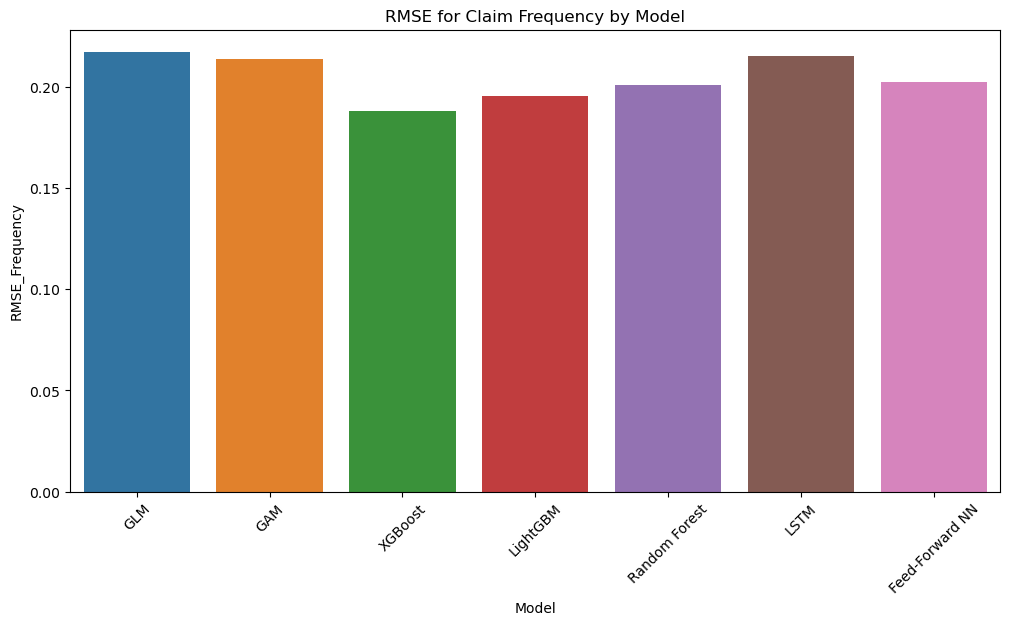

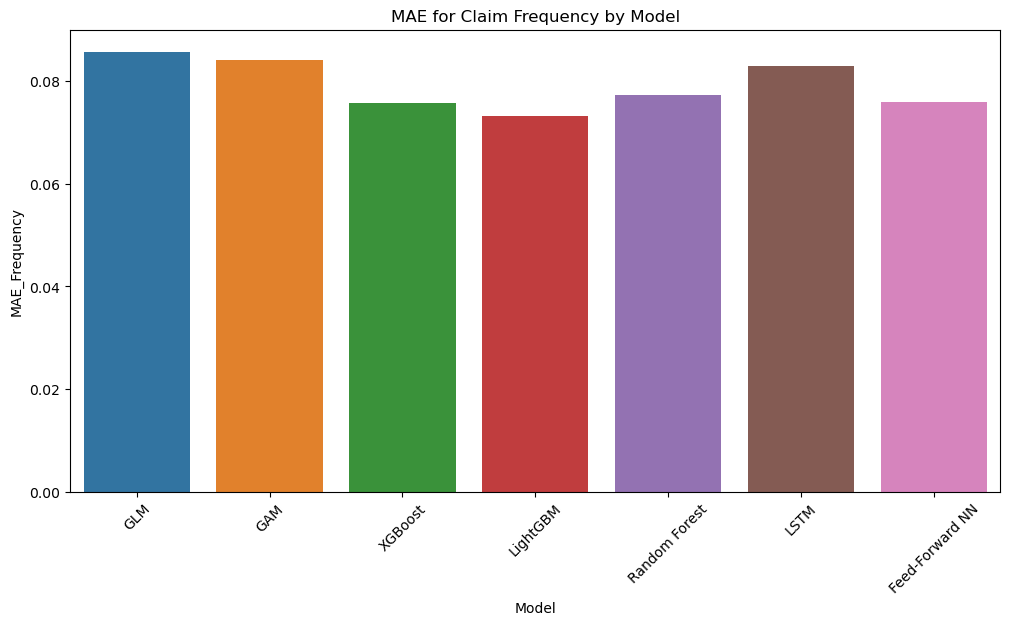

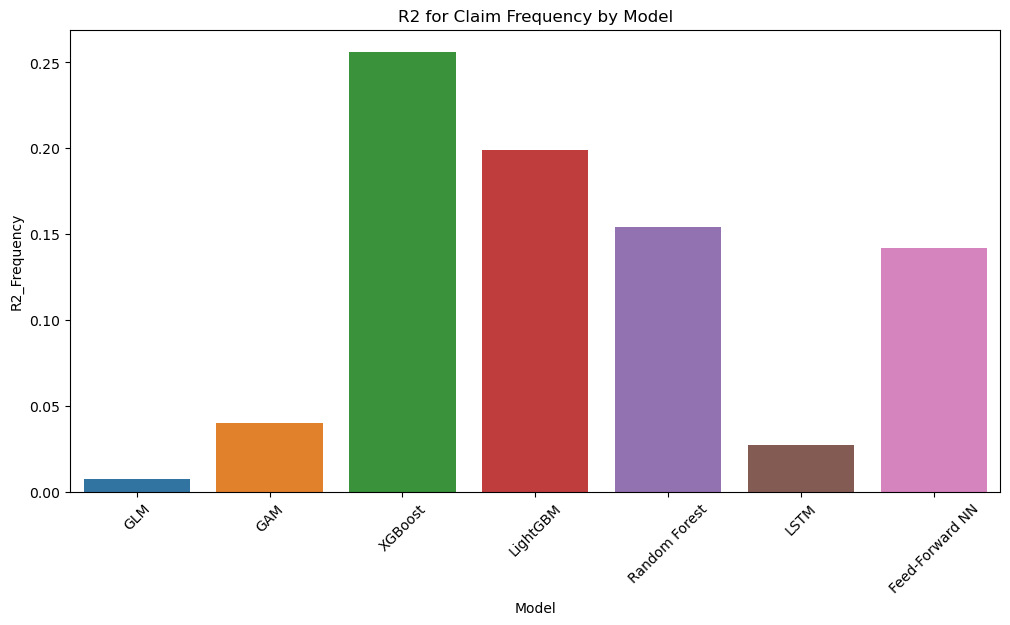

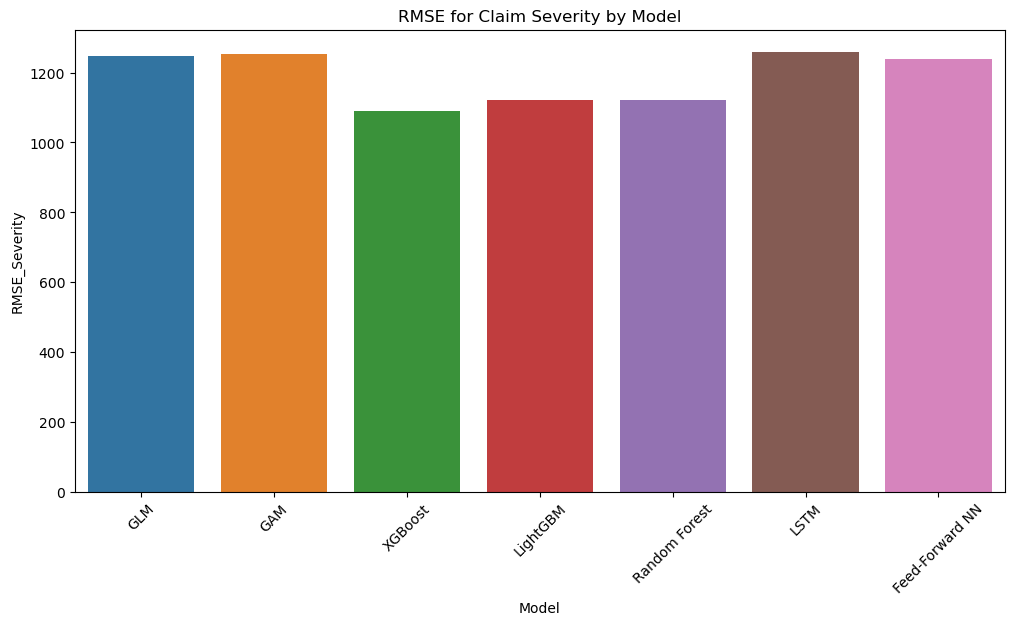

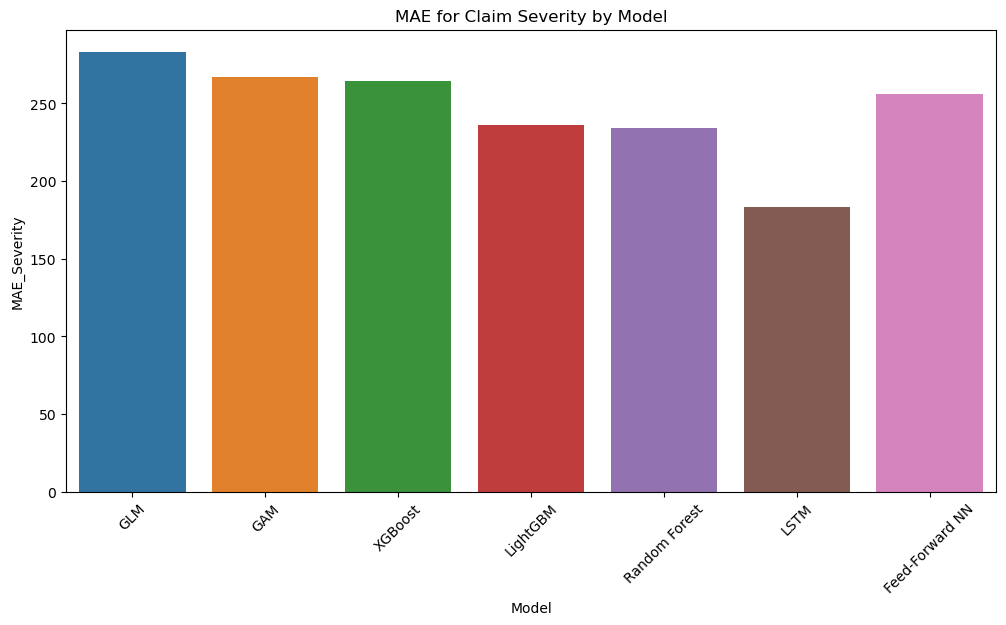

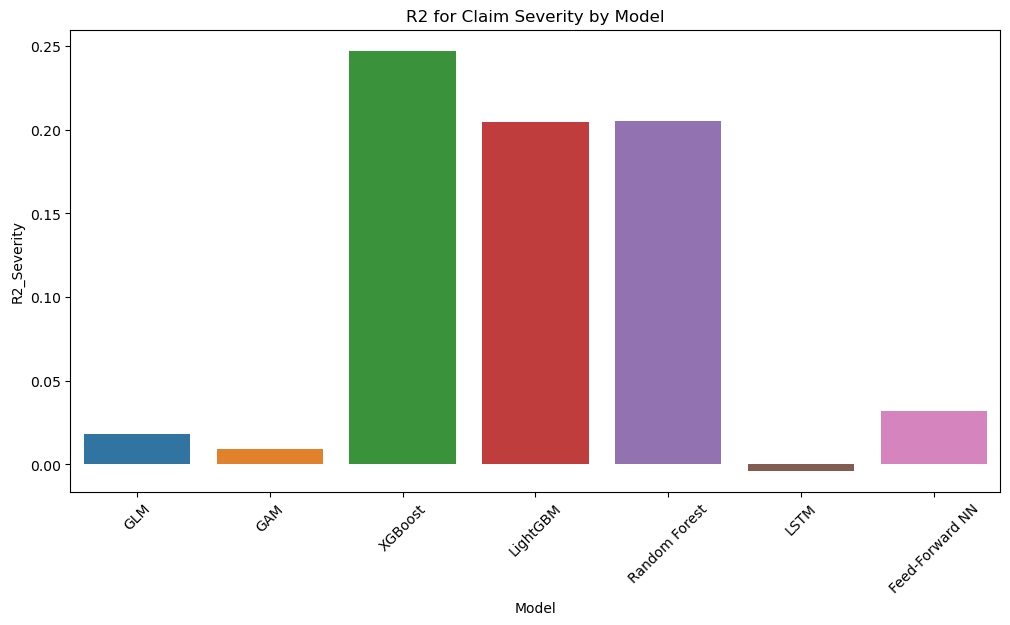

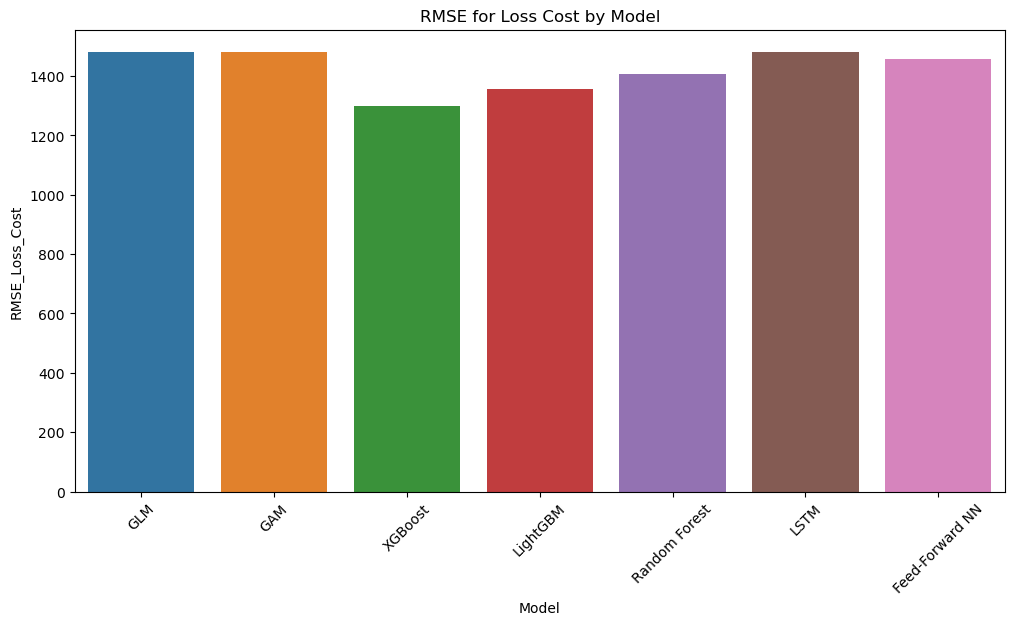

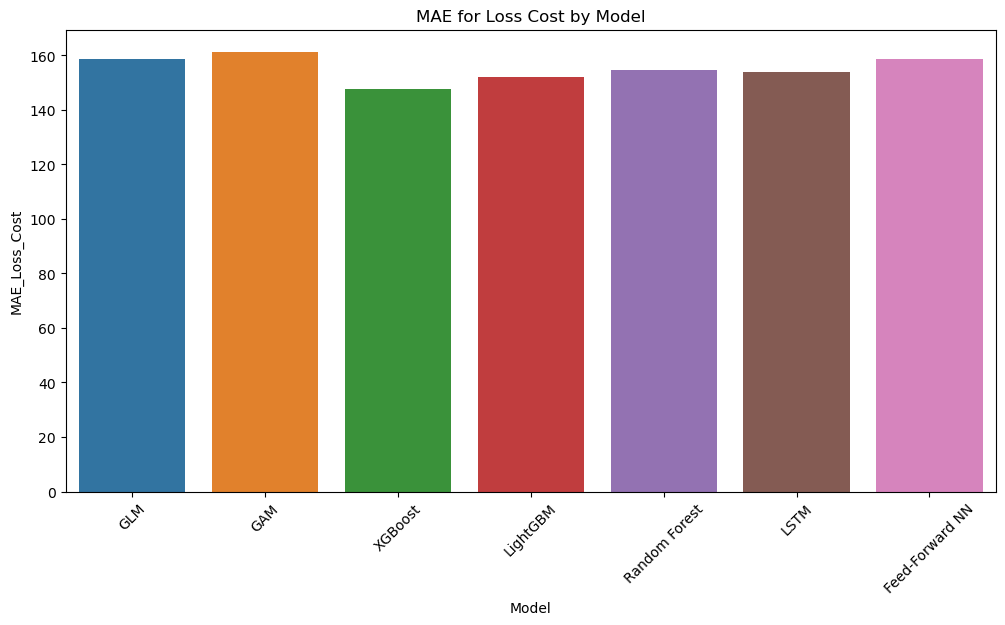

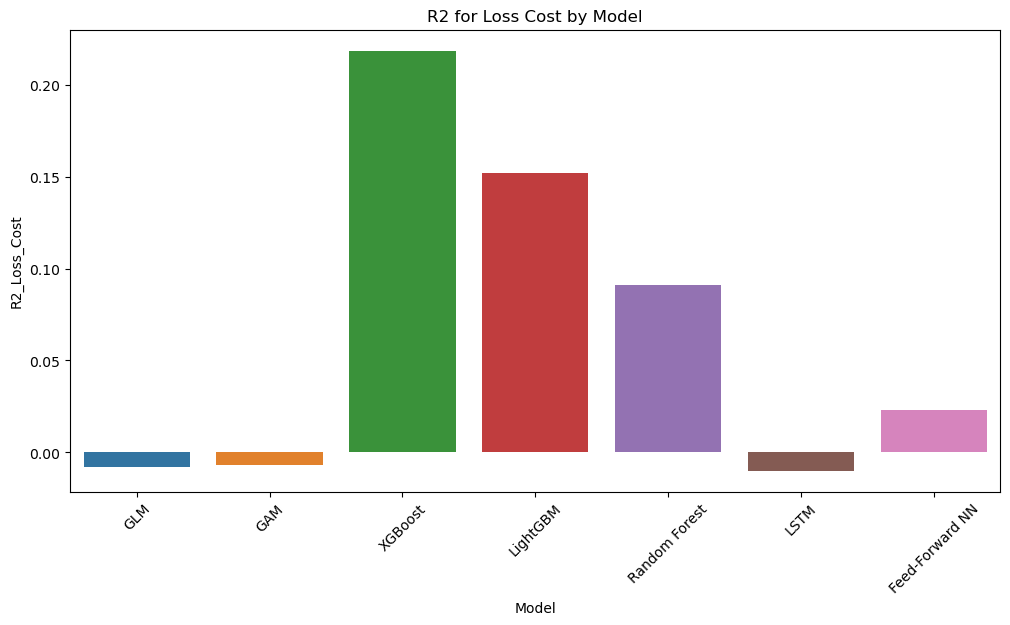

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Save the combined results as a CSV file
results_combined.to_csv('combined_model_results.csv', index=False)

# Print the combined results
print("Combined Results:")
print(results_combined)

# Visualization functions
def plot_metrics(metric, title):
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Model', y=metric, data=results_combined)
    plt.title(title)
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.show()

# Visualize RMSE for Frequency
plot_metrics('RMSE_Frequency', 'RMSE for Claim Frequency by Model')

# Visualize MAE for Frequency
plot_metrics('MAE_Frequency', 'MAE for Claim Frequency by Model')

# Visualize R2 for Frequency
plot_metrics('R2_Frequency', 'R2 for Claim Frequency by Model')

# Visualize RMSE for Severity
plot_metrics('RMSE_Severity', 'RMSE for Claim Severity by Model')

# Visualize MAE for Severity
plot_metrics('MAE_Severity', 'MAE for Claim Severity by Model')

# Visualize R2 for Severity
plot_metrics('R2_Severity', 'R2 for Claim Severity by Model')

# Visualize RMSE for Loss Cost
plot_metrics('RMSE_Loss_Cost', 'RMSE for Loss Cost by Model')

# Visualize MAE for Loss Cost
plot_metrics('MAE_Loss_Cost', 'MAE for Loss Cost by Model')

# Visualize R2 for Loss Cost
plot_metrics('R2_Loss_Cost', 'R2 for Loss Cost by Model')
